In [3]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval
from pathlib import Path

# Path Management

BASE_DIR = Path.cwd()


In [4]:

# Add Utils to sys.path
UTILS_PATH = BASE_DIR.parent.parent / "Utils"

sys.path.append(str(UTILS_PATH))


from utils import *


Found Pytorch


In [5]:
DATSET_DIR = BASE_DIR.parent.parent.parent/"data"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval

def prepare_bbox_dataframe(dataset):
    """Parses bbox strings and returns a dataframe with dimensions."""
    df = dataset.labels.copy()
    
    # Vectorized conversion of string "(x1, y1, x2, y2)" to numeric width/height
    bboxes = np.array(df['Bounding box'].apply(literal_eval).tolist())
    
    df['width'] = bboxes[:, 2] - bboxes[:, 0]
    df['height'] = bboxes[:, 3] - bboxes[:, 1]
    df['max_side'] = df[['width', 'height']].max(axis=1)
    
    return df

In [22]:
def get_bbox_summary_table(df):
    """Generates a summary table for width and height including standard deviation."""
    # Aggregating mean, std, min, and max
    summary = df[['width', 'height']].agg(['mean', 'std', 'min', 'max']).transpose()
    
    # Renaming columns for better readability in the notebook
    summary.columns = ['Average', 'Std Dev', 'Min', 'Max']
    
    # Optional: Round to 2 decimal places for a cleaner table
    return summary.round(2)

def plot_max_dim_pmf(df, bins=50):
    """Plots the PMF of the maximum dimension to show square-fitting probability."""
    plt.figure(figsize=(10, 6))
    
    # Calculate PMF using a histogram normalized to 1
    sns.histplot(df['max_side'], stat="probability", bins=bins, kde=True, color='purple')
    
    plt.title("PMF of Minimum Square Size Required to Fit Bounding Box")
    plt.xlabel("Square Side Length (Pixels)")
    plt.ylabel("Probability")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

def get_fit_probability(df, square_size=512):
    """Calculates the exact probability that a box fits in a given square size."""
    fits = (df['max_side'] <= square_size).mean()
    print(f"Probability of fitting into a {square_size}x{square_size} square: {fits*100:.2f}%")
    return fits.item()

In [29]:
def plot_bbox_cdf(df, target_sizes=[512, 640, 768],highlight_99=False):
    """Plots the CDF of the maximum dimension and highlights the 99% threshold."""
    
    sorted_max_sides = np.sort(df['max_side'])
    y_values = np.arange(len(sorted_max_sides)) / float(len(sorted_max_sides))

    # Calculate the 99th percentile value
    threshold_99 = np.percentile(sorted_max_sides, 99)
    
    plt.figure(figsize=(10, 6))
    plt.plot(sorted_max_sides, y_values, marker=None, linestyle='--', color='dodgerblue', linewidth=2)
    
    # 1. Plot provided target sizes
    colors = ['red', 'green', 'orange']
    for size, color in zip(target_sizes, colors):
        percentile = (df['max_side'] <= size).mean() * 100
        plt.axvline(x=size, color=color, linestyle='--', alpha=0.5)
        plt.text(size + 5, 0.05, f'{size}px: {percentile:.1f}%', color=color, fontsize=9)

    # 2. Automatically highlight the 99% threshold
    if(highlight_99):
        plt.axvline(x=threshold_99, color='black', linestyle='-', linewidth=1)
        plt.axhline(y=0.99, color='black', linestyle=':', alpha=0.6)
    
    # Text annotation for the 99% mark
    plt.text(threshold_99 + 10, 0.95, f'99% Coverage: {int(threshold_99)}px', 
             color='black', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

    plt.title("CDF: Coverage Analysis for Square Crop Sizes")
    plt.xlabel("Square Side Length (Pixels)")
    plt.ylabel("Cumulative Probability (Coverage)")
    plt.ylim(0, 1.05)
    plt.xlim(0, df['max_side'].max() + 50)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

    return threshold_99

In [9]:
SPLIT = "train"
training_set = PyTorchSPARKDataset(class_map=CLASS_MAP, split=SPLIT, root_dir=DATSET_DIR)
df_bbox_train = prepare_bbox_dataframe(training_set)


In [23]:
get_bbox_summary_table(df_bbox_train)

,Average,Std Dev,Min,Max
width,333.68,136.06,44.0,1023.0
height,331.24,134.16,37.0,1023.0


In [24]:
get_fit_probability(df_bbox_train, square_size=512)

Probability of fitting into a 512x512 square: 82.54%


0.8254166666666667

In [18]:
get_fit_probability(df_bbox_train, square_size=614)

Probability of fitting into a 614x614 square: 92.58%


0.9258333333333333

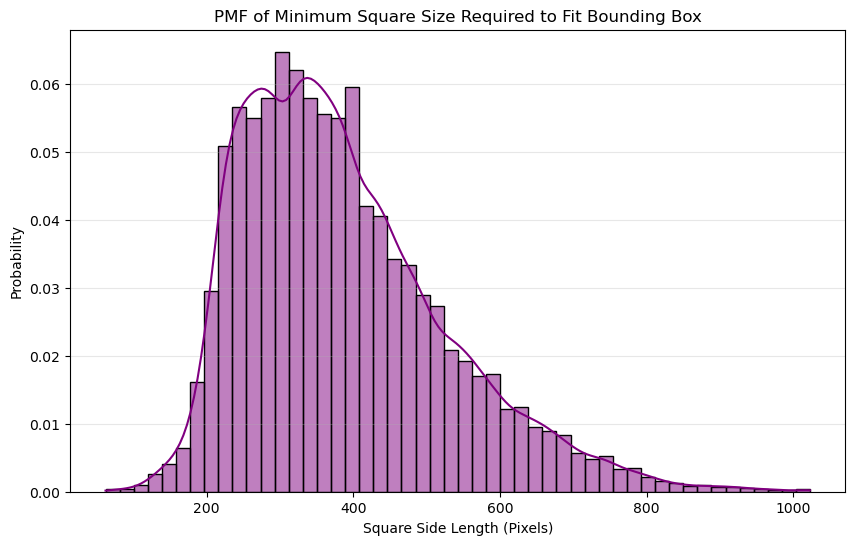

In [19]:

plot_max_dim_pmf(df_bbox_train)

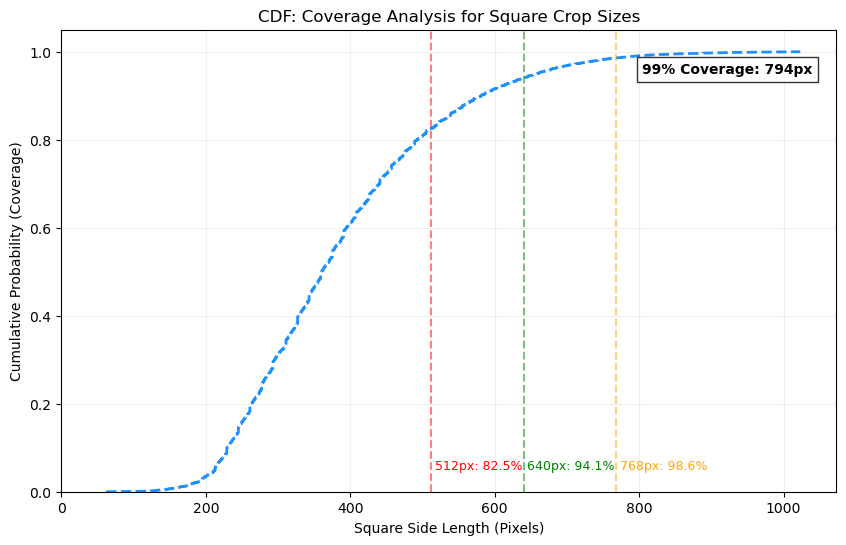

np.float64(794.0)

In [30]:
plot_bbox_cdf(df_bbox_train)

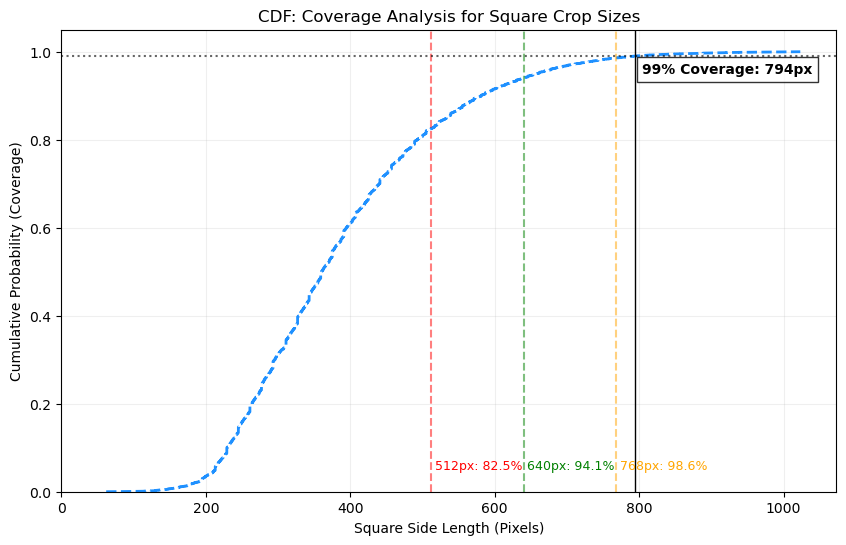

np.float64(794.0)

In [31]:
plot_bbox_cdf(df_bbox_train,highlight_99=True)